# Problema Num 1. Cadenas de Markov.

Segun los promedios de tiempo de verano para predecir el clima, esta determinado por los siguientes comportamientos. Que el ida se mantenga soleado es de un 50%, que de soleado pase a nublado es de un 30% y de soleado a lluvioso un 20%. De nublado para pasar a lluvioso hay una probabilidad del 30%, que se mantenga nublado es de un 50% y que de nublado pase a soleado en un 20% de probabilidad, en el caso de la lluvia se determina que de lluvioso pase a soleado en un 15%, de lluvioso a nublado un 45% y que permanezca lluvioso en el dia es de 40%. Con estos datos y considerando que hoy es DOMINGO, determinar lo siguiente:

Determinar la probabilidad de que el martes este soleado.

Llovera el jueves siguiente y porque si o no.

In [40]:
#importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [41]:
#declarar estados del clima
estados = ['soleado', 'nublado', 'lluvioso']

#declarar matriz con los cambios de clima
cambio_clima = np.array([
    [0.50, 0.30, 0.20],  # De Soleado a: Soleado, Nublado, Lluvioso
    [0.20, 0.50, 0.30],  # De Nublado a: Soleado, Nublado, Lluvioso
    [0.15, 0.45, 0.40]   # De Lluvioso a: Soleado, Nublado, Lluvioso
])

#crear un dataframe para mostrar la matriz de transición
df_P = pd.DataFrame(cambio_clima, index=estados, columns=estados)
print("Matriz de Transición (P):")
print(df_P)
print("\n")

Matriz de Transición (P):
          soleado  nublado  lluvioso
soleado      0.50     0.30       0.2
nublado      0.20     0.50       0.3
lluvioso     0.15     0.45       0.4




In [42]:
#definir el estado inicial (se dice que es Domingo)
estado_inicial_domingo = np.array([0.0, 1.0, 0.0])  # [Soleado, Nublado, Lluvioso]
print("Estado inicial (Domingo - Nublado):")

print(f"Soleado: {estado_inicial_domingo[0]:.2%}")
print(f"Nublado: {estado_inicial_domingo[1]:.2%}")
print(f"Lluvioso: {estado_inicial_domingo[2]:.2%}")
print("\n")

P_2 = np.linalg.matrix_power(cambio_clima, 2)


Estado inicial (Domingo - Nublado):
Soleado: 0.00%
Nublado: 100.00%
Lluvioso: 0.00%




In [43]:
# Calcular la condicion que se presentara el jueves
P_4 = np.linalg.matrix_power(cambio_clima, 4)

# Estado del jueves
estado_jueves = estado_inicial_domingo @ P_4

print("PROBABILIDADES PARA EL JUEVES (4 días después)")
print(f"Soleado: {estado_jueves[0]:.4f} ({estado_jueves[0]:.2%})")
print(f"Nublado: {estado_jueves[1]:.4f} ({estado_jueves[1]:.2%})")
print(f"Lluvioso: {estado_jueves[2]:.4f} ({estado_jueves[2]:.2%})")
print("\n")

prob_lluvia_jueves = estado_jueves[2]

PROBABILIDADES PARA EL JUEVES (4 días después)
Soleado: 0.2621 (26.21%)
Nublado: 0.4331 (43.31%)
Lluvioso: 0.3049 (30.48%)




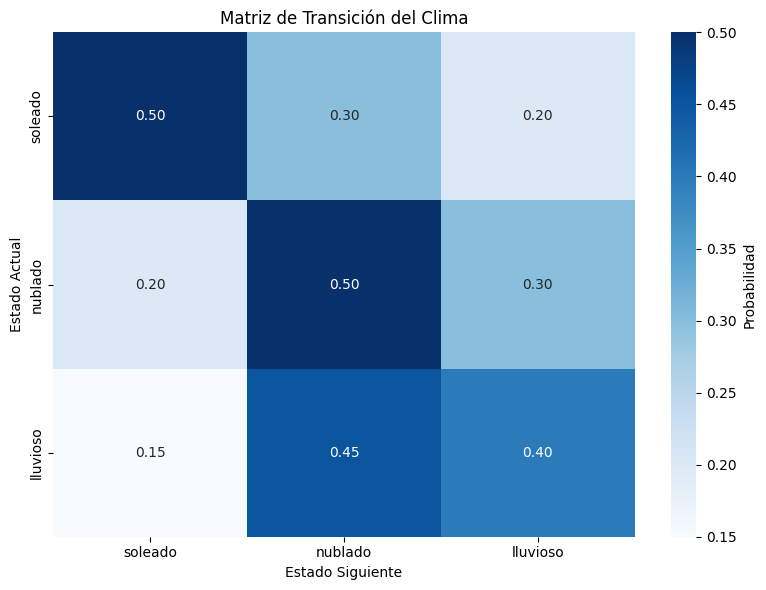

In [44]:
# Visualizar la matriz de transición
plt.figure(figsize=(8, 6))
sns.heatmap(df_P, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'Probabilidad'})
plt.title('Matriz de Transición del Clima')
plt.xlabel('Estado Siguiente')
plt.ylabel('Estado Actual')
plt.tight_layout()
plt.show()

In [45]:
print("Analisis: ¿Llovera el jueves?")

prob_lluvia_jueves = estado_jueves[2]

print(f"\nProbabilidad de lluvia el jueves: {prob_lluvia_jueves:.4f} ({prob_lluvia_jueves:.2%})")
print(f"Probabilidad de NO lluvia el jueves: {1 - prob_lluvia_jueves:.4f} ({(1 - prob_lluvia_jueves):.2%})")

print("Respuesta:")

if prob_lluvia_jueves > 0.5:
    print(f"\nSi, es probable que llueva el jueves")
    print(f"Razon: La probabilidad de lluvia es {prob_lluvia_jueves:.2%}, que es MAYOR al 50%")
else:
    print(f"\nNO, no es probable que llueva el jueves")
    print(f"Razon: La probabilidad de lluvia es {prob_lluvia_jueves:.2%}, que es MENOR al 50%")

print(f"\nEl estado mas probable para el jueves es: {estados[np.argmax(estado_jueves)]}")
print(f"Con una probabilidad de: {np.max(estado_jueves):.2%}")

# Comparar probabilidades de los 3 estados
print("Resumen de probabilidades para el jueves:")
for i, estado in enumerate(estados):
    print(f"  {estado.capitalize():12s}: {estado_jueves[i]:6.2%}")

Analisis: ¿Llovera el jueves?

Probabilidad de lluvia el jueves: 0.3049 (30.48%)
Probabilidad de NO lluvia el jueves: 0.6951 (69.51%)
Respuesta:

NO, no es probable que llueva el jueves
Razon: La probabilidad de lluvia es 30.48%, que es MENOR al 50%

El estado mas probable para el jueves es: nublado
Con una probabilidad de: 43.31%
Resumen de probabilidades para el jueves:
  Soleado     : 26.21%
  Nublado     : 43.31%
  Lluvioso    : 30.48%


# Problema Num 2. Lineas de Espera.

El banco Americano ofrece sericios bancarios con 4 cajas que atienden a los clientes por riguroso orden de llegada. El tiempo de servicio se distribuye exponencialmente, con un promedio de 7 clientes por hora. Los clientes esperan, formando una sola fila y sus llegadas tienen una distribucion de Poisson, con un promedio de 25 clientes por hora.

Cantidad promedio de clientes en cola?

Cantidad promedio de clientes en el sistema?

Tiempo promedio en cola?

Tiempo promedio de permanencia en el sistema?

In [46]:
#importar librerias extras
from math import exp
from math import factorial

In [47]:
#declarar variables
λ = 25  # Tasa de llegada: 25 clientes por hora
μ = 7   # Tasa de servicio: 7 clientes por hora (por caja)
c = 4   # Número de cajas (servidores)

print(" Lineas de espera.")
print(f"\nDatos:")
print(f"  λ (tasa de llegada) = {λ} clientes/hora")
print(f"  μ (tasa de servicio) = {μ} clientes/hora por caja")
print(f"  c (número de cajas) = {c}")


 Lineas de espera.

Datos:
  λ (tasa de llegada) = 25 clientes/hora
  μ (tasa de servicio) = 7 clientes/hora por caja
  c (número de cajas) = 4


In [48]:
# Calcular el factor de utilizacion
ρ = λ / (c * μ)
print(f"\nfactor de utilizacion = {λ}/({c}·{μ}) = {ρ:.4f}")

suma_factorial = 0
for n in range(c):
    suma_factorial += ((λ/μ) ** n) / factorial(n)

P0 = 1 / (suma_factorial + (((λ/μ) ** c) / factorial(c)) * (1 / (1 - ρ)))

print(f"\nP0 (probabilidad de que no haya clientes) = {P0:.6f}")

# Calcular Lq (cantidad promedio de clientes en cola)
numerador = ((λ/μ) ** c) / factorial(c)
Lq = (numerador * ρ) / ((1 - ρ) ** 2) * P0

print(f"\nLq (cantidad promedio de clientes en cola) = {Lq:.4f} clientes")

# Calcular L (cantidad promedio de clientes en el sistema)
L = Lq + (λ / μ)

print(f"L (cantidad promedio de clientes en el sistema) = {L:.4f} clientes")

# Calcular Wq (tiempo promedio en cola)
Wq = Lq / λ  # en horas
Wq_minutos = Wq * 60  # convertir a minutos

print(f"\nWq (tiempo promedio en cola) = {Wq:.6f} horas = {Wq_minutos:.4f} minutos")

# Calcular W (tiempo promedio de permanencia en el sistema)
W = L / λ  # en horas
W_minutos = W * 60  # convertir a minutos

print(f"W (tiempo promedio en el sistema) = {W:.6f} horas = {W_minutos:.4f} minutos")

# Resultado finales
print("Resultados finales:")
print(f"\n1. Cantidad promedio de clientes en cola: {Lq:.4f} clientes")
print(f"2. Cantidad promedio de clientes en el sistema: {L:.4f} clientes")
print(f"3. Tiempo promedio en cola: {Wq_minutos:.4f} minutos ({Wq:.6f} horas)")
print(f"4. Tiempo promedio de permanencia en el sistema: {W_minutos:.4f} minutos ({W:.6f} horas)")
print(f"\nFactor de utilizacion del sistema: {ρ:.2%}")


factor de utilizacion = 25/(4·7) = 0.8929

P0 (probabilidad de que no haya clientes) = 0.012223

Lq (cantidad promedio de clientes en cola) = 6.4447 clientes
L (cantidad promedio de clientes en el sistema) = 10.0161 clientes

Wq (tiempo promedio en cola) = 0.257788 horas = 15.4673 minutos
W (tiempo promedio en el sistema) = 0.400645 horas = 24.0387 minutos
Resultados finales:

1. Cantidad promedio de clientes en cola: 6.4447 clientes
2. Cantidad promedio de clientes en el sistema: 10.0161 clientes
3. Tiempo promedio en cola: 15.4673 minutos (0.257788 horas)
4. Tiempo promedio de permanencia en el sistema: 24.0387 minutos (0.400645 horas)

Factor de utilizacion del sistema: 89.29%
